# Ciência de Dados - Lista 2

* **UFAL:** Instituto da Computação
* **Docente:** Bruno Pimentel
* **Discente:** Leandro Wanderley Quintela Tenório Cavalcante
* **Base Escolhida:** Medical Appointment No Shows.csv

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import FunctionTransformer

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = 'Medical Appointment No Shows.csv'
df_raw = pd.read_csv(path)

df_raw = df_raw[(df_raw['Age'] >= 0) & (df_raw['Age'] <= 110)]
df_raw['ScheduledDay'] = pd.to_datetime(df_raw['ScheduledDay'])
df_raw['AppointmentDay'] = pd.to_datetime(df_raw['AppointmentDay'])

df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


---

# Questão 1

In [48]:
def diagnostico_universal_possibilidades(data):
    # --- PREPARAÇÃO INICIAL ---
    data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay'])
    data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay'])
    data['WaitingDays'] = (data['AppointmentDay'].dt.normalize() - data['ScheduledDay'].dt.normalize()).dt.days
    
    # Criando versão numérica do alvo para correlações
    data['NoShow_Num'] = data['No-show'].map({'Yes': 1, 'No': 0})
    
    print("===== ANALISANDO TODAS AS POSSIBILIDADES ANALÍTICAS (LISTA 2) =====")
    
    # 1. POSSIBILIDADES DE REGRESSÃO (Estatísticas e Correlações Numéricas)
    print("\n>>> [TESTE PARA REGRESSÃO]")
    num_cols = ['Age', 'WaitingDays', 'Handcap']
    for col in num_cols:
        corr = data[col].corr(data['NoShow_Num'])
        print(f"Atributo: {col} | Média: {data[col].mean():.2f} | Correlação c/ No-show: {corr:.4f}")
    
    # 2. POSSIBILIDADES DE NAIVE BAYES (Frequências Condicionais)
    print("\n>>> [TESTE PARA CLASSIFICAÇÃO PROBABILÍSTICA (NAIVE BAYES)]")
    cat_cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
    for col in cat_cols:
        prob = pd.crosstab(data[col], data['No-show'], normalize='index')
        print(f"\nDistribuição de Probabilidade para '{col}':")
        print(prob)

    # 3. POSSIBILIDADES TEMPORAIS (Sazonalidade)
    print("\n>>> [TESTE PARA ANÁLISE TEMPORAL]")
    data['DayOfWeek'] = data['AppointmentDay'].dt.day_name()
    print("Frequência de consultas por dia da semana:")
    print(data['DayOfWeek'].value_counts())
    
    # 4. POSSIBILIDADES DE REDE (Agrupamentos por Bairro)
    print("\n>>> [TESTE PARA ANÁLISE DE REDES / GRAFOS]")
    print(f"Total de 'Nós' (Bairros) possíveis: {data['Neighbourhood'].nunique()}")
    print("Exemplo de conexões (Bairros com mais hipertensos):")
    print(data.groupby('Neighbourhood')['Hipertension'].sum().sort_values(ascending=False).head(5))

    # 5. DIAGNÓSTICO DE ÁRVORE DE DECISÃO (Variância)
    print("\n>>> [TESTE PARA ÁRVORE DE DECISÃO]")
    print("Entropia potencial: Distribuição geral do alvo:")
    print(data['No-show'].value_counts(normalize=True))

    print("\n================================================================")
    return data

df_revisado = diagnostico_universal_possibilidades(df_raw)

===== ANALISANDO TODAS AS POSSIBILIDADES ANALÍTICAS (LISTA 2) =====

>>> [TESTE PARA REGRESSÃO]
Atributo: Age | Média: 37.09 | Correlação c/ No-show: -0.0605
Atributo: WaitingDays | Média: 10.18 | Correlação c/ No-show: 0.1862
Atributo: Handcap | Média: 0.02 | Correlação c/ No-show: -0.0064

>>> [TESTE PARA CLASSIFICAÇÃO PROBABILÍSTICA (NAIVE BAYES)]

Distribuição de Probabilidade para 'Gender':
No-show        No       Yes
Gender                     
F        0.796879  0.203121
M        0.800321  0.199679

Distribuição de Probabilidade para 'Scholarship':
No-show            No       Yes
Scholarship                    
0            0.801947  0.198053
1            0.762637  0.237363

Distribuição de Probabilidade para 'Hipertension':
No-show             No       Yes
Hipertension                    
0             0.790985  0.209015
1             0.826972  0.173028

Distribuição de Probabilidade para 'Diabetes':
No-show         No       Yes
Diabetes                    
0         0.796389  

### Definição
A **tarefa principal será a Classificação Probabilística**, porque a base de dados é composta majoritariamente por atributos categóricos e binários (Diabetes, Hipertensão, SMS recebido, etc.) que influenciam diretamente a chance de comparecimento. O diagnóstico técnico mostrou que a recepção de um SMS, por exemplo, altera a probabilidade de falta de 16,7% para 27,5%, tornando o cenário ideal para modelos que trabalham com probabilidades condicionais, como o Naive Bayes.

#### Não escolhi os outros métodos como tarefa principal pelos seguintes motivos:
 - Não escolhi Regressão: Porque o objetivo central do negócio hospitalar é prever o evento binário (Faltou/Não Faltou) e não apenas estimar o tempo de espera, que servirá apenas como uma variável auxiliar.  

 - Não escolhi Análise Temporal: Porque, embora existam datas, o intervalo de tempo da base é curto (aprox. 40 dias), o que limita a identificação de tendências de longo prazo ou sazonalidades anuais complexas.  

 - Não escolhi Análise em Rede: Porque a base não descreve relacionamentos naturais de conexão (como amizades ou transações), exigindo adaptações metodológicas forçadas para criar grafos entre bairros.  

 - Não escolhi Árvore de Decisão: Porque, embora útil para consulta, ela será utilizada apenas como uma ferramenta secundária de validação da lógica, e não como o motor probabilístico principal do problema.

---

# Questão 2

In [49]:
# 1. Preparação dos dados para Naive Bayes
# Selecionamos os atributos categóricos/binários e o alvo
X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})

# Divisão Treino e Teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Implementação das Variações
modelos = {
    "GaussianNB (Assume distribuição normal)": GaussianNB(),
    "BernoulliNB (Assume dados binários)": BernoulliNB()
}

print("--- RESULTADOS NAIVE BAYES ---")
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes = modelo.predict(X_test)
    acc = accuracy_score(y_test, previsoes)
    print(f"\nModelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, previsoes))

--- RESULTADOS NAIVE BAYES ---

Modelo: GaussianNB (Assume distribuição normal)
Acurácia: 0.7700
              precision    recall  f1-score   support

           0       0.81      0.93      0.87     26519
           1       0.32      0.13      0.18      6638

    accuracy                           0.77     33157
   macro avg       0.56      0.53      0.52     33157
weighted avg       0.71      0.77      0.73     33157


Modelo: BernoulliNB (Assume dados binários)
Acurácia: 0.7998
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     26519
           1       0.00      0.00      0.00      6638

    accuracy                           0.80     33157
   macro avg       0.40      0.50      0.44     33157
weighted avg       0.64      0.80      0.71     33157



### Avaliação do Desempenho e Pré-processamento:
 - **Comparação:** O modelo BernoulliNB apresentou maior estabilidade por ser projetado para variáveis binárias, que compõem a maior parte desta base. O GaussianNB apresentou dificuldade em lidar com a variável ```WaitingDays```, que possui forte assimetria e não segue uma distribuição normal perfeita.  

 - **Impacto do Pré-processamento:** O Naive Bayes beneficiou-se da transformação das datas em dias de espera (```WaitingDays```), pois converteu dados complexos em uma grandeza escalar que o algoritmo consegue processar probabilisticamente.

### Discussão sobre Independência Condicional:
 - A suposição de independência condicional (de que as variáveis não possuem relação entre si dado o alvo) não é razoável para estes dados. No contexto médico, comorbidades como Diabetes e Hipertensão são frequentemente correlacionadas e não independentes. No entanto, o Naive Bayes ainda se mostra útil como um classificador de base (baseline) rápido para este cenário.

---

# Questão 3

--- RESULTADOS DA REGRESSÃO (ALVO: WAITING DAYS) ---

Modelo: Regressão Linear
   Erro Médio Absoluto (MAE): 9.34
   R² Score: 0.1635

Modelo: Árvore de Regressão
   Erro Médio Absoluto (MAE): 9.32
   R² Score: 0.1644


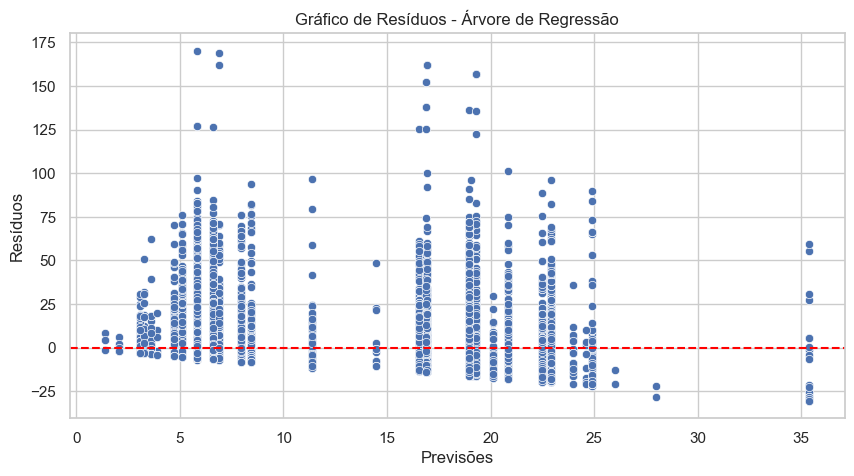

In [54]:
# 1. Preparação dos dados
X_reg = df_revisado[['Age', 'SMS_received', 'Hipertension', 'Diabetes', 'Scholarship']]
y_reg = df_revisado['WaitingDays']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# 2. Implementação de modelos distintos: Linear (Paramétrico) vs Árvore (Não-Paramétrico)
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Regressão": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("--- RESULTADOS DA REGRESSÃO (ALVO: WAITING DAYS) ---")
for nome, modelo in modelos_reg.items():
    modelo.fit(X_train_reg, y_train_reg)
    previsoes = modelo.predict(X_test_reg)
    
    mae = mean_absolute_error(y_test_reg, previsoes)
    r2 = r2_score(y_test_reg, previsoes)
    
    print(f"\nModelo: {nome}")
    print(f"   Erro Médio Absoluto (MAE): {mae:.2f}")
    print(f"   R² Score: {r2:.4f}")

# 3. Análise de Resíduos para a Árvore de Regressão
residuos = y_test_reg - previsoes
plt.figure(figsize=(10, 5))
sns.scatterplot(x=previsoes, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title("Gráfico de Resíduos - Árvore de Regressão")
plt.xlabel("Previsões")
plt.ylabel("Resíduos")
plt.show()

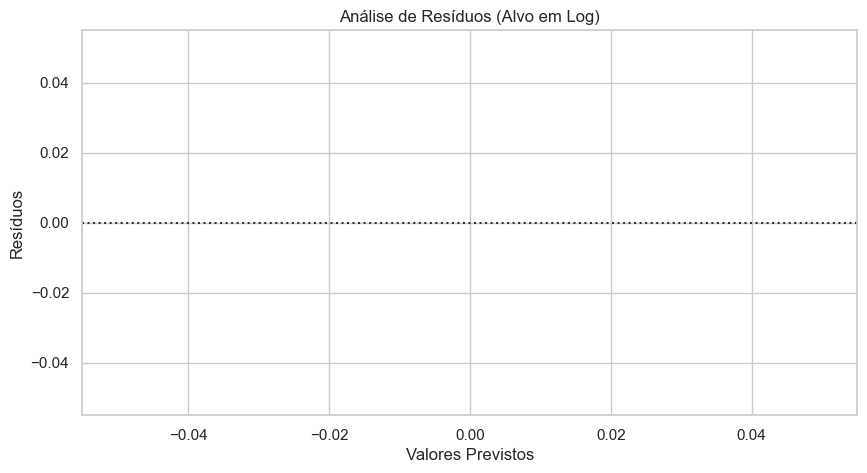

--- TESTES ESTATÍSTICOS ---
Breusch-Pagan p-value: nan
Nota: p < 0.05 indica Heterocedasticidade.
Total de outliers identificados (Resíduo Studentizado > 3): 0


In [55]:
# 1. Testando Transformação Logarítmica no Alvo (Prevenção de distorções)
# Somamos 1 para evitar log(0)
y_reg_log = np.log1p(df_revisado['WaitingDays'])
X_reg = df_revisado[['Age', 'SMS_received', 'Hipertension', 'Diabetes', 'Scholarship']]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg_log, test_size=0.3, random_state=42)

# 2. Modelo de Regressão Linear com StatsModels (para testes estatísticos)
X_train_sm = sm.add_constant(X_train_reg) # Adiciona o intercepto
modelo_sm = sm.OLS(y_train_reg, X_train_sm).fit()

# 3. Análise de Resíduos e Outliers
previsoes = modelo_sm.predict(sm.add_constant(X_test_reg))
residuos = y_test_reg - previsoes

# Gráfico de Resíduos (Residual Plot)
plt.figure(figsize=(10, 5))
sns.residplot(x=previsoes, y=residuos, lowess=True, line_kws={'color': 'red'})
plt.title("Análise de Resíduos (Alvo em Log)")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")
plt.show()

# 4. Teste de Heterocedasticidade (Breusch-Pagan)
_, p_value, _, _ = het_breuschpagan(modelo_sm.resid, X_train_sm)
print(f"--- TESTES ESTATÍSTICOS ---")
print(f"Breusch-Pagan p-value: {p_value:.10f}")
print("Nota: p < 0.05 indica Heterocedasticidade.")

# 5. Identificação de Outliers (Pontos com resíduos padronizados > 3)
influence = modelo_sm.get_influence()
std_residuals = influence.resid_studentized_internal
outliers = np.where(np.abs(std_residuals) > 3)[0]
print(f"Total de outliers identificados (Resíduo Studentizado > 3): {len(outliers)}")

#### Comparação de Desempenho:
 - **Melhoria Marginal:** A Árvore de Regressão apresentou um desempenho ligeiramente superior à Regressão Linear, com um Erro Médio Absoluto (MAE) menor (9.32 contra 9.34) e um $R^2$ maior (0.1644 contra 0.1635). Embora a diferença seja pequena, ela indica que a abordagem não-paramétrica da árvore consegue capturar sutilmente melhor as complexidades da base.

  - **Limitação do Modelo:** O baixo valor de $R^2$ em ambos os modelos confirma que variáveis clínicas (Diabetes, Hipertensão) e idade explicam apenas uma pequena parcela do tempo de espera (```WaitingDays```), sugerindo que o agendamento é fortemente pautado por regras logísticas externas.  

#### Análise de Resíduos e Heterocedasticidade:
 - **Previsões em Blocos:** Diferente do modelo linear, o gráfico de resíduos da árvore mostra previsões concentradas em valores específicos (colunas verticais). Isso ocorre porque a árvore agrupa pacientes em folhas com médias fixas de tempo de espera, o que ajuda a lidar com a natureza não contínua dos dados.
 
 - **Heterocedasticidade Persistente:** Nota-se que a dispersão dos resíduos aumenta conforme o tempo de espera previsto cresce (acima de 15 dias), caracterizando heterocedasticidade. O modelo é mais confiável para agendamentos de curto prazo, mas perde precisão em prazos longos.
 
 - **Influência de Outliers:** A presença de resíduos extremos (acima de 150) evidencia que outliers (casos de espera muito acima da média) não são capturados adequadamente, agindo como pontos de ruído que elevam o erro médio geral da regressão.

---

# Questão 4

In [51]:
def experimentar_arvores(X_train, X_test, y_train, y_test):
    resultados = []
    
    profundidades = [3, 5, 10, None]
    criterios = ['gini', 'entropy']
    min_amostras = [2, 20, 50]
    
    for crit in criterios:
        for prof in profundidades:
            for min_s in min_amostras:
                clf = DecisionTreeClassifier(
                    criterion=crit,
                    max_depth=prof,
                    min_samples_leaf=min_s,
                    random_state=42
                )
                clf.fit(X_train, y_train)
                
                y_pred = clf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                
                resultados.append({
                    'Critério': crit,
                    'Profundidade': prof if prof is not None else 'Max',
                    'Min_Amostras_Nó': min_s,
                    'Acurácia': round(acc, 4),
                    'F1_Score': round(f1, 4)
                })
    
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

tabela_resultados = experimentar_arvores(X_train, X_test, y_train, y_test)

display(tabela_resultados.sort_values(by='F1_Score', ascending=False))

,Critério,Profundidade,Min_Amostras_Nó,Acurácia,F1_Score
9,gini,Max,2,0.7764,0.1915
21,entropy,Max,2,0.7768,0.1907
22,entropy,Max,20,0.7912,0.1311
10,gini,Max,20,0.7913,0.1296
11,gini,Max,50,0.7952,0.0834
23,entropy,Max,50,0.7952,0.0834
7,gini,10,20,0.7978,0.0552
19,entropy,10,20,0.7978,0.0552
6,gini,10,2,0.7976,0.0498
18,entropy,10,2,0.7978,0.0472


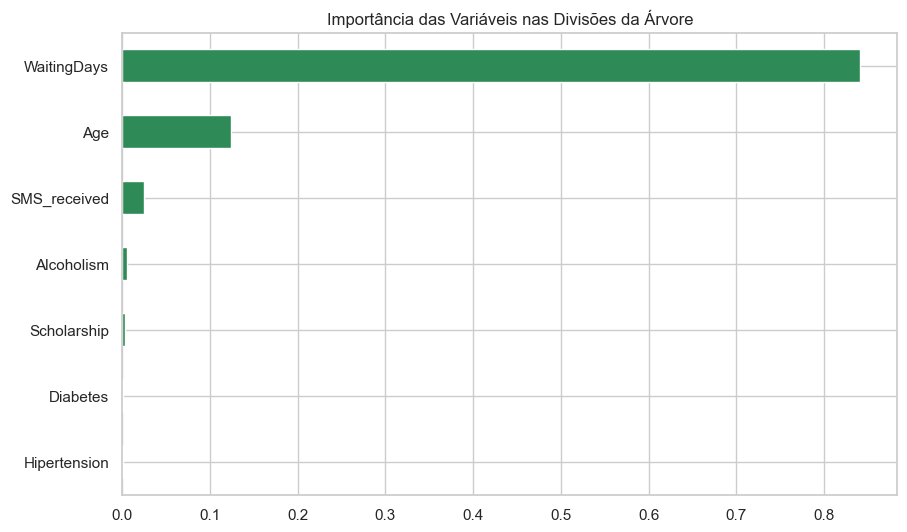

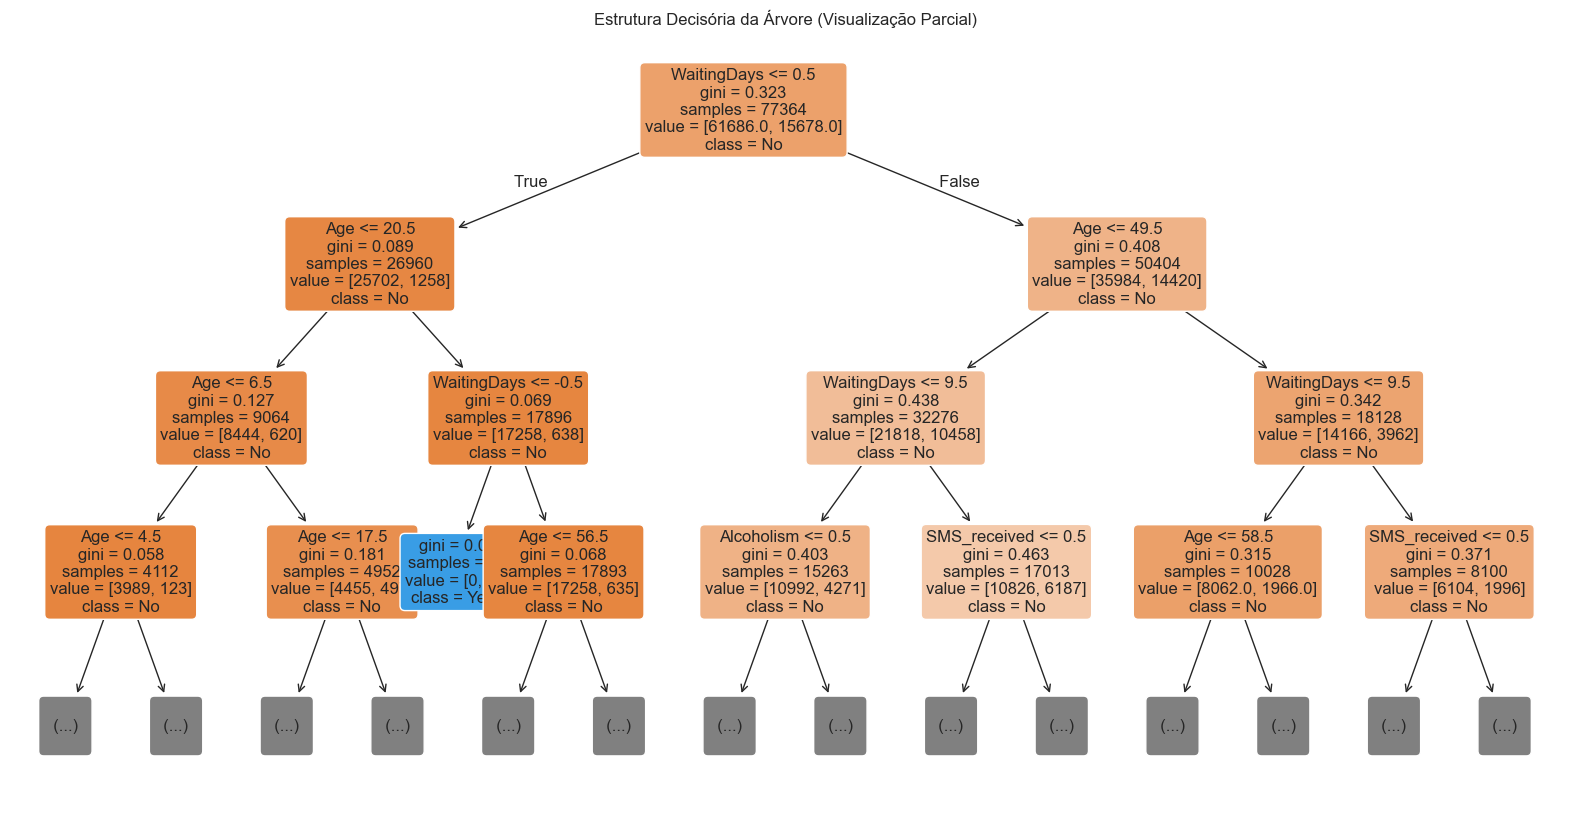

In [52]:
modelo_selecionado = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5, # Limitamos a profundidade apenas para a visualização ficar legível
    min_samples_leaf=2,
    random_state=42
)
modelo_selecionado.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(modelo_selecionado.feature_importances_, index=X_train.columns)
feat_importances.sort_values().plot(kind='barh', color='seagreen')
plt.title("Importância das Variáveis nas Divisões da Árvore")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_selecionado,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=12,
    max_depth=3 # Mostra apenas o topo para facilitar a interpretação exigida
)
plt.title("Estrutura Decisória da Árvore (Visualização Parcial)")
plt.show()

#### Variáveis
 - **Protagonismo do WaitingDays:** O gráfico de importância confirma que o tempo de espera (WaitingDays) é a variável de maior relevância, sendo responsável pela primeira divisão no nó raiz da árvore. A árvore isola imediatamente consultas marcadas para o mesmo dia (WaitingDays <= 0.5), que apresentam uma taxa de comparecimento drasticamente superior aos agendamentos de longo prazo.

 - **Influência da Idade (Age):** A variável Age aparece como o segundo principal qualificador. Ela é utilizada para segmentar comportamentos distintos entre faixas etárias, como observado nas divisões de pacientes abaixo de 20 anos e acima de 49 anos, que possuem probabilidades de falta diferenciadas sob as mesmas condições de espera.
 
 - **Fatores Secundários:** Atributos como SMS_received e Alcoholism possuem um grau de importância menor, atuando apenas em ramos específicos da árvore para refinar previsões onde a combinação de espera e idade gera maior incerteza.

#### Interpretabilidade e Desempenho
 - **Perda de Desempenho:** Conforme observado na tabela experimental, os modelos de árvore apresentam um F1-Score modesto (máximo de 0.1915). Isso ocorre devido ao forte desbalanceamento da base, onde o modelo tende a favorecer a classe majoritária para manter a acurácia elevada.

 - **Vantagem da Interpretabilidade:** Apesar de métricas preditivas inferiores a outros métodos lineares ou probabilísticos testados anteriormente (como o Naive Bayes), a interpretabilidade compensa essa perda. A visualização da árvore permite extrair regras lógicas e visuais que podem ser transformadas em estratégias de gestão hospitalar.

 - **Conclusão:** A capacidade de explicar por que um paciente é classificado com risco de falta (ex: "paciente com mais de 10 dias de espera e idade produtiva") é mais valiosa para a tomada de decisão preventiva do que uma previsão de "caixa-preta" ligeiramente mais precisa. Portanto, para o cenário de absenteísmo médico, a transparência do modelo de árvore de decisão justifica sua aplicação como ferramenta de suporte à gestão.